# Задание 2 (Вариант 5)


# Теоретический анализ

Распределение Пуассона с параметром:

$\qquad
\lambda$ имеет второй момент: $\mu_2 = E[X^2] = \lambda^2 + \lambda
$

Оценка второго момента по выборке:

$\qquad
\hat{\mu}_2 = \frac{1}{n} \sum_{i=1}^n X_i^2
$

По ЦПТ для больших $n$:

$\qquad
\sqrt{n} (\hat{\mu}_2 - \mu_2) \sim N(0, \mathrm{Var}(X^2))
$

Асимптотический доверительный интервал уровня $1-\alpha$:

$\qquad
\hat{\mu}_2 \pm z_{1-\alpha/2} \cdot \sqrt{ \frac{{\mathrm{S^2}}(X^2)}{ n } }
$

$\qquad {\mathrm{S^2}}(X^2)$ - смещенная выборочная дисперсия $X^2$

Покрытие - доля случаев, когда истинное значение $\mu_2$ попадает в построенный интервал.


## Импорты и параметры

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(0)

LAMBDA = 1

MU2_TRUE = LAMBDA**2 + LAMBDA

ALPHA = 0.05
ITERATIONS = 1000


## Функция эксперимента


In [21]:
def experiment(n):
    covers = 0
    ci_widths = []
    for _ in range(ITERATIONS):
        X = np.random.poisson(LAMBDA, n)
        mu2_hat = np.mean(X**2)
        var_hat = np.var(X**2, ddof=1)
        z = norm.ppf(1 - ALPHA/2)
        ci_lower = mu2_hat - z * np.sqrt(var_hat / n)
        ci_upper = mu2_hat + z * np.sqrt(var_hat / n)
        ci_widths.append(ci_upper - ci_lower)
        if ci_lower <= MU2_TRUE <= ci_upper:
            covers += 1
    coverage = covers / ITERATIONS
    avg_width = np.mean(ci_widths)
    return coverage, avg_width


## Эксперимент


In [22]:
RESULTS = {}
for n in [25, 10000]:
    coverage, avg_width = experiment(n)
    RESULTS[n] = (coverage, avg_width)
    print(f'Размер выборки: {n}')
    print(f'Покрытие: {coverage:.6f}')
    print(f'Средняя ширина доверительного: {avg_width:.6f}')
    print()


Размер выборки: 25
Покрытие: 0.879000
Средняя ширина доверительного: 2.386044

Размер выборки: 10000
Покрытие: 0.955000
Средняя ширина доверительного: 0.130058

Размер выборки: 10000
Покрытие: 0.955000
Средняя ширина доверительного: 0.130058



## Визуализация

### Ширина интервала и покрытие в зависимости от размера выборки


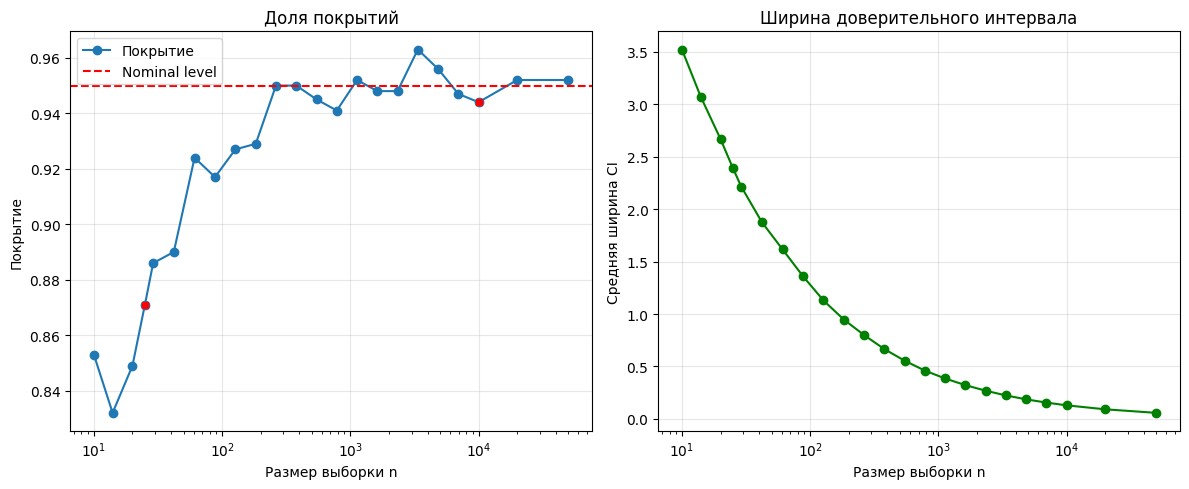

In [ ]:
SIZES = np.logspace(1, 4, 20, dtype=int)
SIZES = np.unique(np.concatenate([
    SIZES,
    [25, 10000, 20000, 50000]
]))

def plot():
    coverages = []
    widths = []
    for n in SIZES:
        cov, w = experiment(n)
        coverages.append(cov)
        widths.append(w)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(SIZES, coverages, 'o-', label='Покрытие')
    plt.axhline(1-ALPHA, color='red', linestyle='--', label='Nominal level')
    plt.xlabel('Размер выборки n')
    plt.ylabel('Покрытие')
    plt.title('Доля покрытий')
    plt.xscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    for control_n in [25, 10000]:
        idx = np.where(SIZES == control_n)[0][0]
        plt.plot(control_n, coverages[idx], 's', color='red', markersize=5)

    plt.subplot(1, 2, 2)
    plt.plot(SIZES, widths, 'o-g', label='Ширина CI')
    plt.xlabel('Размер выборки n')
    plt.ylabel('Средняя ширина CI')
    plt.title('Ширина доверительного интервала')
    plt.xscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

plot()


## Вывод:

### При увеличении объёма выборки доверительный интервал становится уже, а покрытие приближается к теоретическому уровню.
